<a href="https://colab.research.google.com/github/hk666890/SEM-VI--A2/blob/main/IPMV_Exp1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
import numpy as np
import urllib.request

def exp1_point_processing():
    # --------------------------------------------------------
    # STEP 1: Download a sample image (Lena image)
    # --------------------------------------------------------
    # URL of standard test image used in image processing
    url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg"
    # Download the image and save it as lena.png
    urllib.request.urlretrieve(url, "lena.png")

    # Read the image in grayscale mode
    # 0 indicates grayscale image
    img = cv2.imread("lena.png", 0)

    # --------------------------------------------------------
    # STEP 2: Image Negative
    # Formula: s = 255 - r
    # This operation inverts pixel intensities
    # --------------------------------------------------------
    img_negative = 255 - img

    # --------------------------------------------------------
    # STEP 3: Logarithmic Transformation
    # Used to enhance darker regions in an image
    # --------------------------------------------------------
    # Calculate scaling constant 'c'
    c = 255 / np.log(1 + np.max(img))
    # Apply log transformation
    img_log = c * np.log(img + 1)
    # Convert image to unsigned 8-bit integer format
    img_log = np.array(img_log, dtype=np.uint8)

    # --------------------------------------------------------
    # STEP 4: Power Law (Gamma) Transformation
    # Used for gamma correction
    # --------------------------------------------------------
    gamma = 2.2 # Gamma value
    img_power = np.array(255 * (img / 255) ** gamma, dtype=np.uint8)

    # --------------------------------------------------------
    # STEP 5: Contrast Stretching
    # Improves contrast by expanding intensity range
    # --------------------------------------------------------
    min_val, max_val = 50, 200
    img_stretched = np.uint8(
    np.clip((img-min_val) * (255 / (max_val-min_val)), 0, 255)
    )

    # --------------------------------------------------------
    # STEP 6: Bit Plane Slicing
    # Extract the most significant bit (7th bit)
    # --------------------------------------------------------
    bit_plane_7 = (img >> 7) * 255

    # --------------------------------------------------------
    # STEP 7: Prepare for Display
    # --------------------------------------------------------
    images = [img, img_negative, img_log, img_power, img_stretched, bit_plane_7]
    titles = [
        "Original Image",
        "Negative Image",
        "Log Transformation",
        "Power Law Transformation",
        "Contrast Stretching",
        "7th Bit Plane"
    ]
    return images, titles

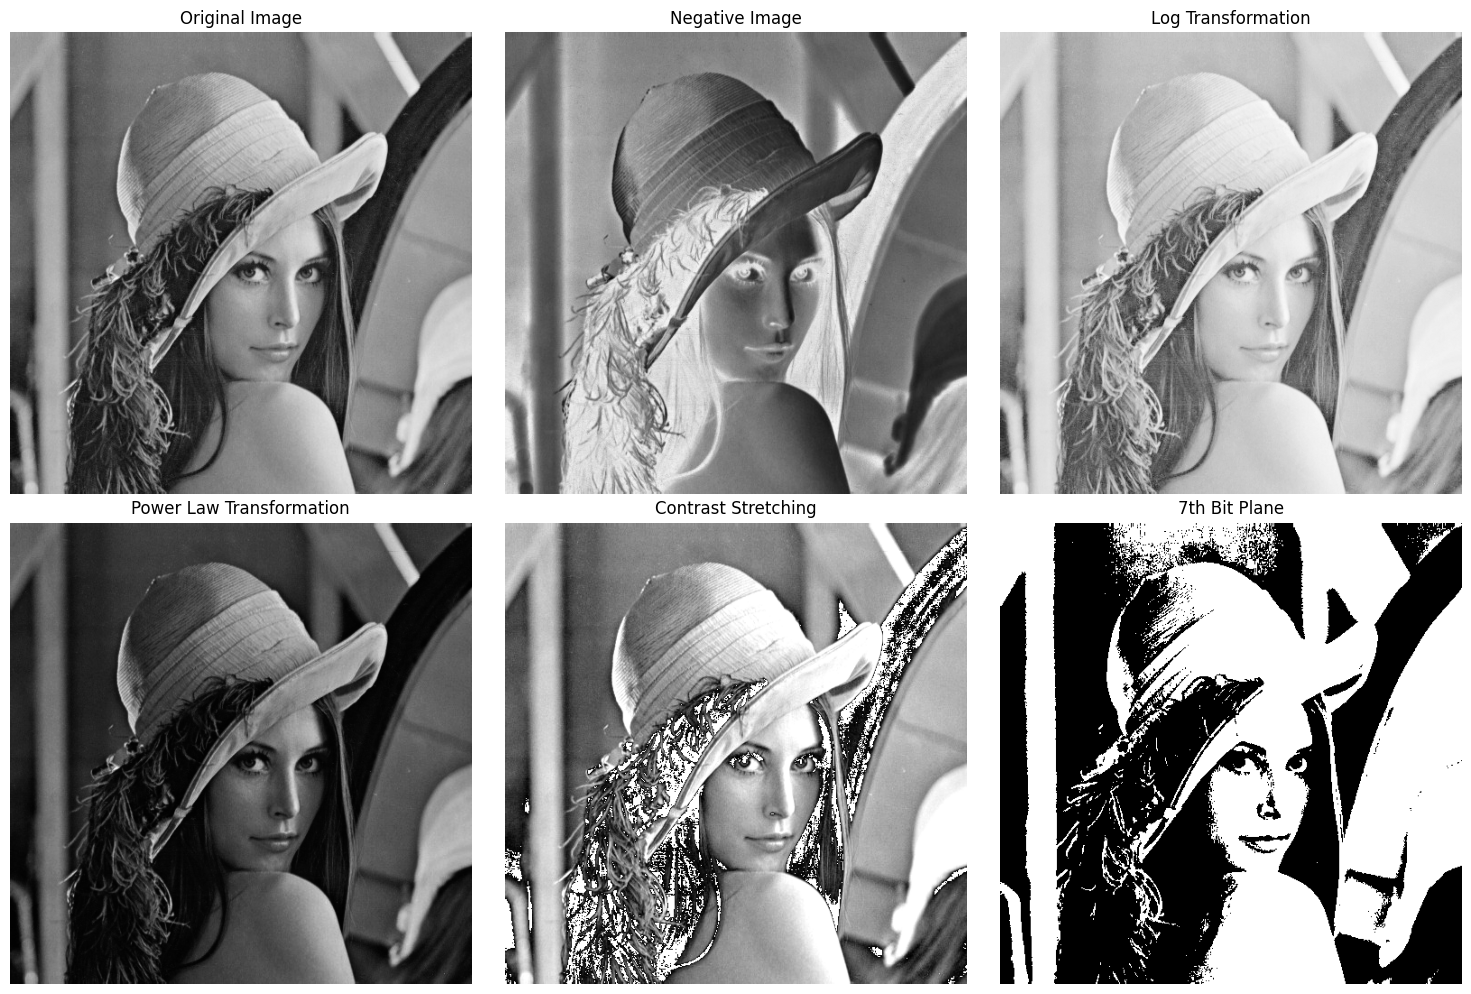

In [ ]:
import matplotlib.pyplot as plt

# Execute the point processing function
images, titles = exp1_point_processing()

# Create a figure window
plt.figure(figsize=(15, 10))
# Display images in 2 rows and 3 columns
for i in range(len(images)):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

# Adjust spacing and show images
plt.tight_layout()
plt.show()